<a href="https://colab.research.google.com/github/Baronlegend27/academic-research-to-financial-freedom/blob/main/papers/Fama%20%26%20French%20%20%E2%80%9CThe%20Equity%20Premium%E2%80%9D%20(2002)/The_Equity_Premium.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Used the data "F-F_Research_Data_Factors.csv" for this.

In [9]:
from google.colab import files

# This will open a file dialog to choose your file
uploaded = files.upload()

In [10]:
import pandas as pd

df = pd.read_csv(
    "F-F_Research_Data_Factors.csv",
    skiprows=3,      # adjust based on your file
    sep=",",         # Fama-French CSVs are comma-separated
    index_col=0      # first column is usually the date
)
print(df.head())

         Mkt-RF      SMB      HML       RF
192607     2.89    -2.55    -2.39     0.22
192608     2.64    -1.14     3.81     0.25
192609     0.38    -1.36     0.05     0.23
192610    -3.27    -0.14     0.82     0.32
192611     2.54    -0.11    -0.61     0.31


In [11]:

# # Equity Premium Analysis using Fama-French 3-Factor Data
#
# This notebook analyzes the equity premium using the Fama-French 3-Factor monthly dataset.
# - **Mkt-RF** is the market excess return (market return minus risk-free rate), in percent.
# - **RF** is the risk-free rate, in percent.
# - We compute the equity premium, summary statistics, and visualizations.


# Install required packages (if not already installed)
!pip install statsmodels matplotlib seaborn --quiet


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from datetime import datetime

plt.style.use("seaborn-v0_8")



# Drop footer rows that are not in YYYYMM format (e.g., yearly aggregates)
df = df[df.index.astype(str).str.match(r'^\d{6}$', na=False)]

# Convert index from YYYYMM (e.g., 192607) to month-end DatetimeIndex
df.index = pd.to_datetime(df.index.astype(str), format="%Y%m") + pd.offsets.MonthEnd(0)

# Convert all columns to float and from percent to decimal
df = df.apply(pd.to_numeric, errors='coerce') / 100.0

# Check required columns
required_cols = ['Mkt-RF', 'SMB', 'HML', 'RF']
missing = [col for col in required_cols if col not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Compute equity premium and gross market return
df['EquityPremium'] = df['Mkt-RF']            # already market excess return (Mkt - RF)
df['Market'] = df['Mkt-RF'] + df['RF']       # market return (Mkt)

# Show cleaned data
print("Cleaned Data (head):")
print(df.head())
print("\nCleaned Data (tail):")
print(df.tail())


# Summary statistics
n_months = len(df)
start_date = df.index.min()
end_date = df.index.max()

mean_monthly = df['EquityPremium'].mean()
std_monthly = df['EquityPremium'].std()
# Annualize mean and std (approximate)
mean_annual = (1 + mean_monthly) ** 12 - 1
std_annual = std_monthly * np.sqrt(12)
# Annualized average risk-free rate (approx)
rf_annual = (1 + df['RF'].mean()) ** 12 - 1
sharpe_ratio = (mean_annual - rf_annual) / std_annual

# Newey-West t-statistic for mean > 0 using OLS with constant and HAC covariance (maxlags=12)
X = np.ones((n_months, 1))
y = df['EquityPremium'].values
model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags':12})
t_stat = model.tvalues[0]
p_value = model.pvalues[0]
conf_int = model.conf_int(alpha=0.05)  # 95% CI for monthly mean
monthly_ci_lower, monthly_ci_upper = conf_int[0, 0], conf_int[0, 1]
# Convert monthly CI to annualized approximate CI (compounding)
annual_ci_lower = (1 + monthly_ci_lower) ** 12 - 1
annual_ci_upper = (1 + monthly_ci_upper) ** 12 - 1

print(f"Sample period: {start_date.date()} to {end_date.date()} ({n_months} months)")
print(f"Mean monthly equity premium: {mean_monthly:.6f}")
print(f"Annualized mean (compounded): {mean_annual:.6f}")
print(f"Monthly std dev: {std_monthly:.6f}")
print(f"Annualized std dev: {std_annual:.6f}")
print(f"Annualized Sharpe ratio: {sharpe_ratio:.3f}")
print(f"Newey-West t-stat (mean > 0): {t_stat:.3f}, p-value: {p_value:.4f}")
print(f"95% CI for annualized mean: ({annual_ci_lower:.6f}, {annual_ci_upper:.6f})")



Cleaned Data (head):
            Mkt-RF     SMB     HML      RF  EquityPremium  Market
1926-07-31  0.0289 -0.0255 -0.0239  0.0022         0.0289  0.0311
1926-08-31  0.0264 -0.0114  0.0381  0.0025         0.0264  0.0289
1926-09-30  0.0038 -0.0136  0.0005  0.0023         0.0038  0.0061
1926-10-31 -0.0327 -0.0014  0.0082  0.0032        -0.0327 -0.0295
1926-11-30  0.0254 -0.0011 -0.0061  0.0031         0.0254  0.0285

Cleaned Data (tail):
            Mkt-RF     SMB     HML      RF  EquityPremium  Market
2025-09-30  0.0339 -0.0185 -0.0105  0.0033         0.0339  0.0372
2025-10-31  0.0196 -0.0055 -0.0310  0.0037         0.0196  0.0233
2025-11-30 -0.0013  0.0038  0.0376  0.0030        -0.0013  0.0017
2025-12-31 -0.0036 -0.0106  0.0242  0.0034        -0.0036 -0.0002
2026-01-31  0.0102  0.0221  0.0370  0.0030         0.0102  0.0132
Sample period: 1926-07-31 to 2026-01-31 (1195 months)
Mean monthly equity premium: 0.006918
Annualized mean (compounded): 0.086253
Monthly std dev: 0.053053
Annualiz

The cleaned dataset shows monthly U.S. equity returns from July 1926 to January 2026, including Fama-French factors (Mkt-RF, SMB, HML), the risk-free rate (RF), and the computed equity premium. The mean monthly equity premium is 0.69%, which annualizes to roughly 8.6%, with an annualized standard deviation of 18.4%. The Newey-West t-statistic (4.21, p ≈ 0) indicates the equity premium is statistically positive, and the 95% confidence interval for the annualized mean ranges from 4.5% to 12.9%, suggesting a historically reliable excess return over the risk-free rate.

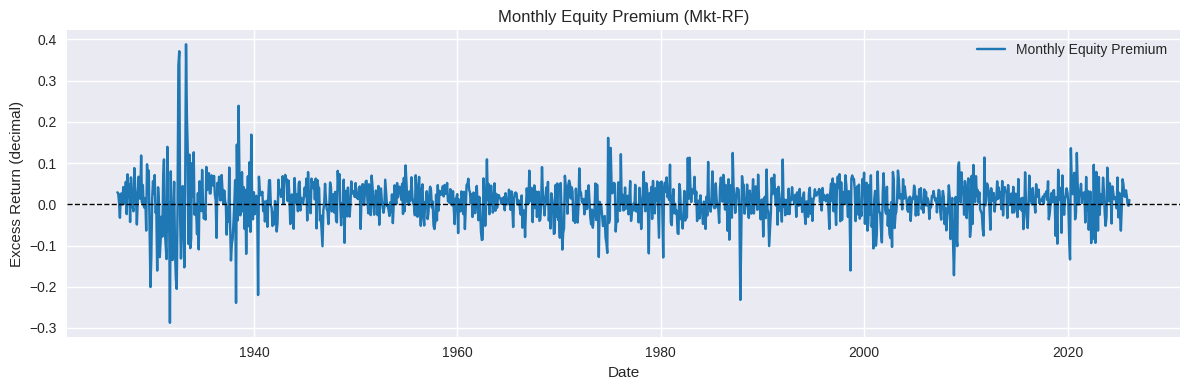

In [12]:
# Plot: Monthly equity premium time series
plt.figure(figsize=(12,4))
plt.plot(df.index, df['EquityPremium'], label='Monthly Equity Premium', color='tab:blue')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title("Monthly Equity Premium (Mkt-RF)")
plt.ylabel("Excess Return (decimal)")
plt.xlabel("Date")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



The chart shows the monthly equity premium (Mkt-RF) from the 1920s to the 2020s, illustrating that equities generally earn positive returns above the risk-free rate. Extreme swings in the 1930s highlight pre-war volatility, while post-WWII fluctuations are smaller but still significant (e.g., 2000, 2008). For Fama and French, this persistent positive premium underpins their three-factor model, making Mkt-RF the key factor and motivating the inclusion of size (SMB) and value (HML) factors, since market risk alone cannot fully explain returns.

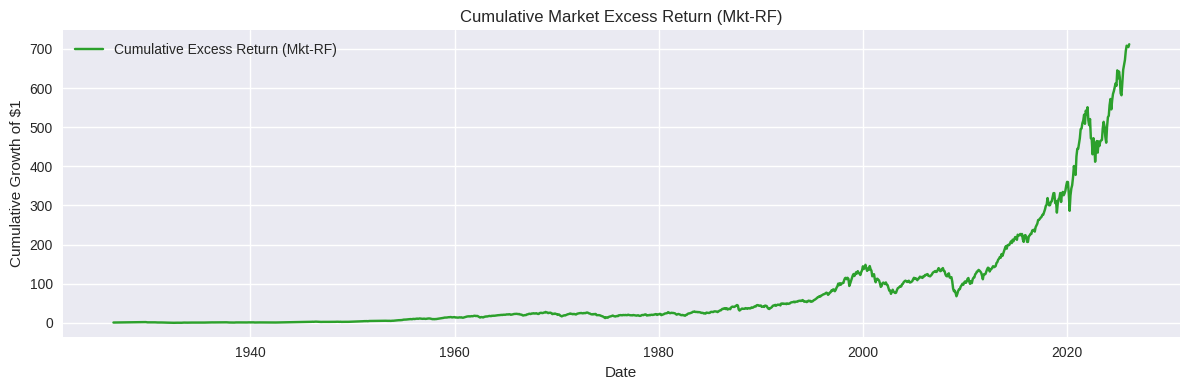

In [13]:
# Plot: Cumulative excess return (starting at 1)
cum_excess = (1 + df['EquityPremium']).cumprod()

plt.figure(figsize=(12,4))
plt.plot(df.index, cum_excess, label='Cumulative Excess Return (Mkt-RF)', color='tab:green')
plt.title("Cumulative Market Excess Return (Mkt-RF)")
plt.ylabel("Cumulative Growth of $1")
plt.xlabel("Date")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



This chart shows the cumulative growth of USD 1 invested in the market excess return (Mkt-RF) from the late 1920s through 2025, compounding every month. Here is what it shows and why it matters:

**What the chart shows:**

Growth is nearly flat from the 1930s through the 1970s, not because the market wasn't growing, but because **compounding is slow in the early decades** when the base is small and volatility is high. The curve begins accelerating visibly in the **1980s and 1990s**, reflecting the long bull market of that era, before the dotcom crash around 2000 briefly cuts the cumulative value roughly in half. It then recovers and **explodes upward from roughly 2010 onward**, ending near USD 700 by the mid-2020s. The extreme convexity of the right side of the chart is a classic illustration of **exponential compounding** over long horizons.

**Significance to Fama and French:**

This chart is essentially a long-run validation of the equity premium as a **real, persistent, and economically large** phenomenon, which is the bedrock assumption of Fama and French's framework. The fact that USD 1 grew to nearly USD 700 above the risk-free rate over roughly 95 years confirms that market risk is consistently rewarded. For Fama and French, this justifies Mkt-RF as the anchor factor in their model. It also illustrates why investors need additional factors like SMB and HML to explain the **cross-sectional variation in returns**, if the market factor alone explained everything, all stocks would have converged to this same cumulative path, which they clearly do not.

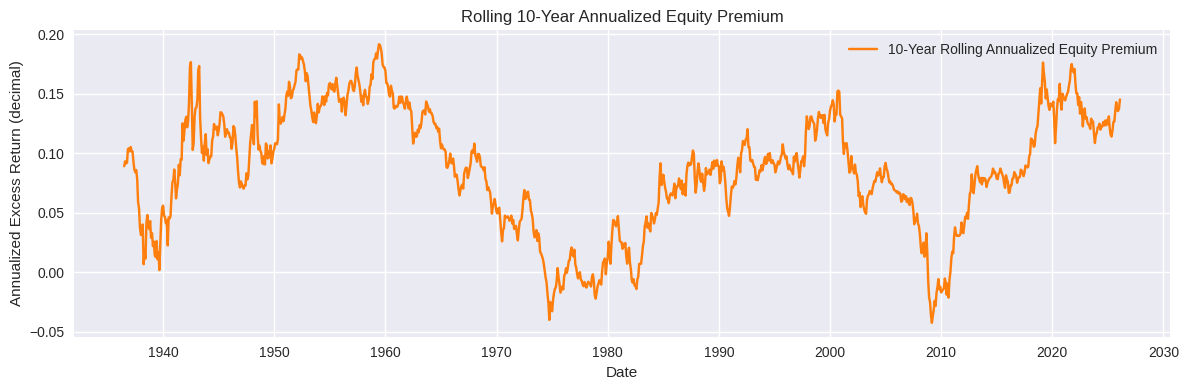

In [14]:
# Plot: Rolling 10-year (120-month) annualized equity premium
rolling_window = 120
rolling_mean = df['EquityPremium'].rolling(window=rolling_window).mean()
rolling_annualized = (1 + rolling_mean) ** 12 - 1

plt.figure(figsize=(12,4))
plt.plot(df.index, rolling_annualized, label='10-Year Rolling Annualized Equity Premium', color='tab:orange')
plt.title("Rolling 10-Year Annualized Equity Premium")
plt.ylabel("Annualized Excess Return (decimal)")
plt.xlabel("Date")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


This chart shows the rolling 10-year annualized equity premium at each point in time — meaning for any given date, it shows the average annual excess return the market delivered over the **prior 10 years**. This is more revealing than the cumulative chart because it strips out compounding and shows how the premium **fluctuates across different decades**.

**What the chart shows:**

The premium is highly variable, ranging from nearly **+20% annualized** in the late 1940s and late 1950s down to **negative territory** in the mid-1970s and again around 2009, meaning there were 10-year stretches where the market actually underperformed the risk-free rate. The series broadly oscillates in a range of roughly 0% to 18%, with no clear tendency to converge to a stable long-run value within any given investor's horizon. Notably the premium **recovers strongly after every trough**, but the troughs themselves can last years.

**Significance to Fama and French:**

This chart is particularly important because it directly confronts a tension in the Fama-French framework. Their model treats the equity premium as a **stable, positive expected return** that compensates for systematic risk — but this chart shows it is anything but stable in realized terms. This is actually consistent with their broader worldview: Fama and French argue that the premium is **time-varying and only reliably positive over very long horizons**, which is why their empirical work spans decades of data rather than short windows. The negative readings around 1975 and 2009 also reinforce why they insist on using **long-run average returns** rather than recent returns when estimating factor premia.

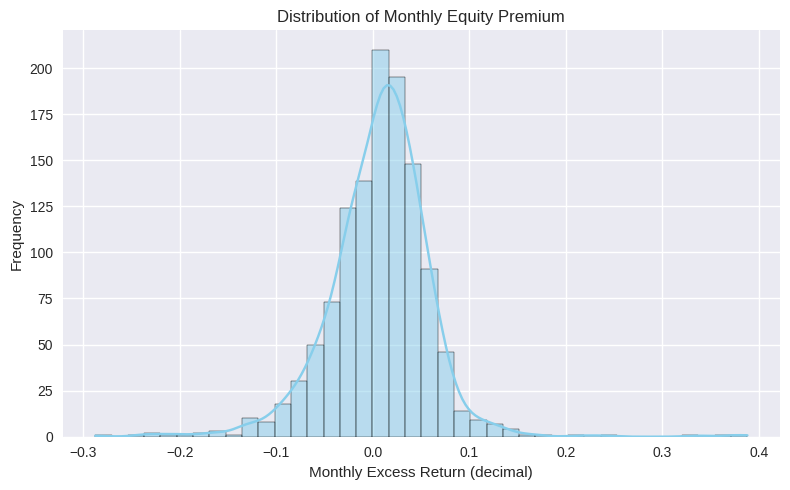

In [15]:
# Histogram of monthly equity premium with KDE
plt.figure(figsize=(8,5))
sns.histplot(df['EquityPremium'].dropna(), bins=40, kde=True, color='skyblue')
plt.title("Distribution of Monthly Equity Premium")
plt.xlabel("Monthly Excess Return (decimal)")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()



This chart shows the full distribution of monthly equity premium observations across the entire sample, with a kernel density curve overlaid.

**What the chart shows:**

The distribution is **centered just above zero**, confirming the positive average equity premium. It is roughly bell-shaped but with two important deviations from normality. First, it is **negatively skewed**, the left tail extends much further (down to -0.30) than the right tail (up to ~0.40), meaning large negative months are more extreme than large positive ones. Second, it shows **fat tails** on both sides relative to a normal distribution, with the density curve fitting the center well but underrepresenting the extreme observations. The bulk of monthly returns cluster tightly between roughly -0.10 and +0.10.

**Significance to Fama and French:**

This distribution has two key implications for their framework. First, the **positive center mass**, most months cluster around a small positive excess return, validates the equity premium as a genuine and recurring phenomenon, not just an artifact of a few outlier months. Second, and more importantly, the **fat tails and negative skew** are exactly why Fama and French argue that the CAPM is insufficient. If returns were normally distributed with stable variance, beta would fully capture risk. The presence of extreme downside events that occur more frequently than a normal distribution would predict suggests there are **additional dimensions of risk**, precisely what SMB and HML are designed to capture. This distributional evidence supports their argument that investors need to be compensated for more than just market beta.